# KAN → SDP Bridge: KAN-Assisted Tomography

Instead of running KAN and SDP as competitors, run them
**in series**:

```
raw noisy data → [KAN] → smooth surface → evaluate on a CLEAN uniform grid → [SDP] → matrix Π₁
   (3720 pts,      learns    p₁(|α|²,θ)      (you choose the phases,            physical
    jittery)       denoised                   perfectly uniform)                POVM
```

**Why this makes the backward (matrix) step easier:**
1. **Denoising** — the KAN averaged out shot noise when it fit the surface, so its predictions are
   cleaner than any single raw measurement.
2. **Clean grid** — you can evaluate the KAN at *any* phase, so you build a perfectly uniform phase
   grid. The recursive SDP's phase-average (SI Eq. 1) then becomes *exact* — no trapezoid trick, no
   offset artifact (the very bug that plagued the raw-data recursion).

The KAN does the hard denoising/interpolation; the SDP does the physics (positivity → valid POVM).

**Prerequisite:** run the three-way notebook first (or paste its setup), so `X, y, Xtr, Xte, ytr,
yte, D, L, GAMMA, logfac, born_predict, rms, model, featurize, stats` are defined.

rows: 3720 | |a|^2 0.178..38.5 | theta 0.01..6.28 | p1 0.001..0.997
train: 2976  test: 744


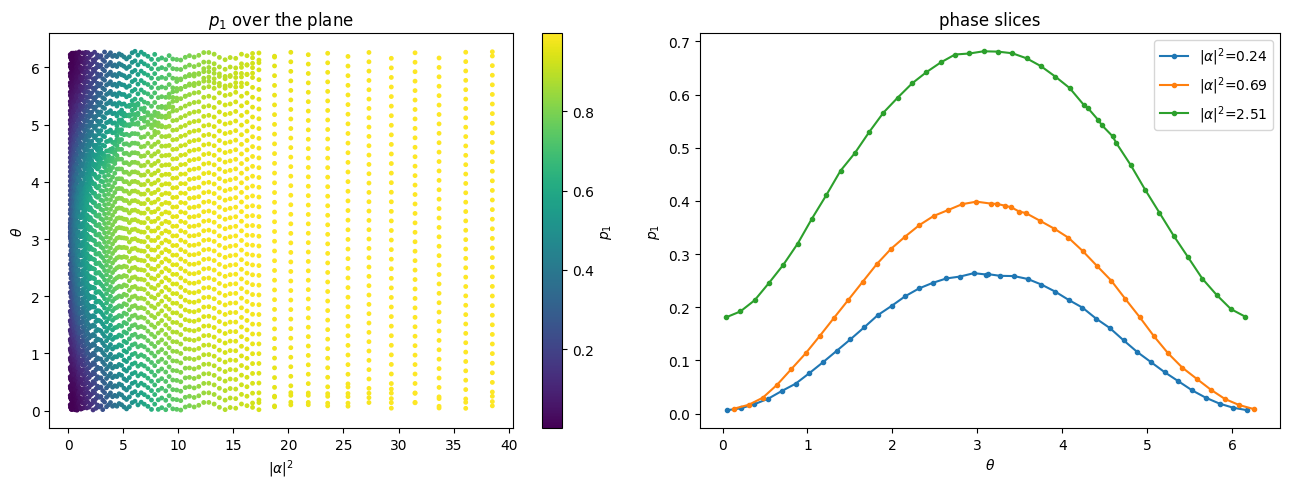

D=58  max leakage over data: 2.04e-03
KAN inputs ready: (2976, 2) -> (2976,)
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.10e-03 | test_loss: 3.31e-03 | reg: 8.02e+00 | : 100%|█| 60/60 [00:05<00:00, 11.87it


saving model version 0.1
saving model version 0.2


| train_loss: 2.99e-03 | test_loss: 3.27e-03 | reg: 8.07e+00 | : 100%|█| 40/40 [00:03<00:00, 11.39it


saving model version 0.3
saving model version 0.4


| train_loss: 2.86e-03 | test_loss: 3.20e-03 | reg: 8.13e+00 | : 100%|█| 40/40 [00:03<00:00, 10.79it

saving model version 0.5
KAN  test RMS : 0.00320


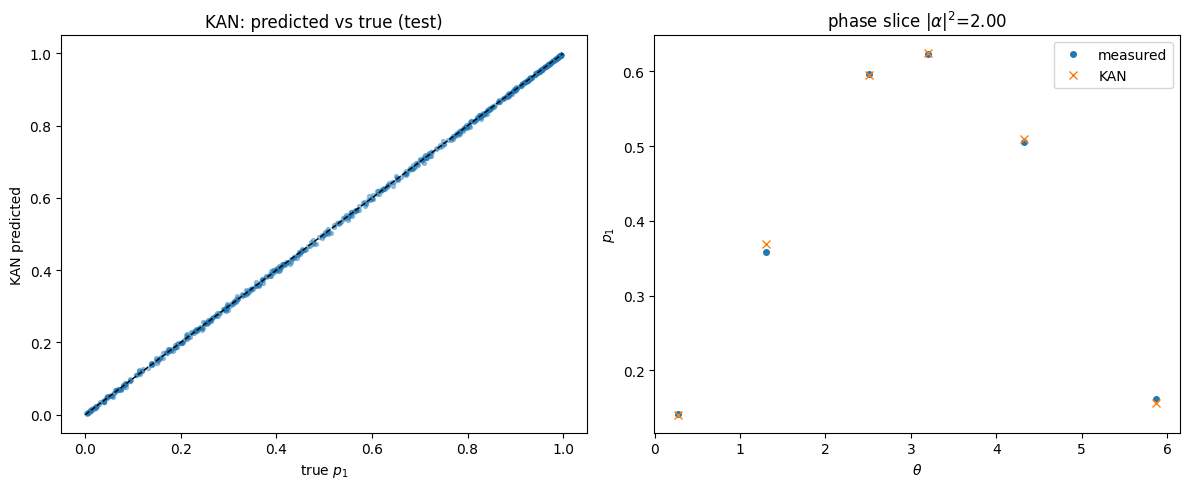

KAN_assisted_tomography_MOESM4_SDP_joint and recursive.ipynb:14: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  "| **KAN** | a probability surface $p_1(\\lvert\\alpha\\rvert^2,\\theta)$ (no matrix, no physics) | test RMS directly |\n",
/Users/lensa/Term_3/Research/papers/Quantum Paper/.venv/lib/python3.12/site-packages/cvxpy/atoms/affine/binary_operators.py:192: RuntimeWarning: divide by zero encountered in matmul
  return values[0] @ values[1]
/Users/lensa/Term_3/Research/papers/Quantum Paper/.venv/lib/python3.12/site-packages/cvxpy/atoms/affine/binary_operators.py:192: RuntimeWarning: overflow encountered in matmul
  return values[0] @ values[1]
/Users/lensa/Term_3/Research/papers/Quantum Paper/.venv/lib/python3.12/site-packages/cvxpy/atoms/affine/binary_operators.py:192: RuntimeWarning: invalid value encountered in matmul
  return values[0] @ values[1]
KAN_assisted_tomography_MOESM4_SDP_joint and recursive.ipy

JOINT  test RMS 0.00320 | eig [0.0007, 1.0000] | valid POVM: True
l=1  imag/real ratio 0.030  (should be small)
l=2  imag/real ratio 0.210  (should be small)
l=3  imag/real ratio 0.578  (should be small)
l=4  imag/real ratio 0.882  (should be small)
l=0 | diagonal rises 0.114 -> 0.998 (max 0.999) | fit RMS 0.00430
l=1 | max|off| 0.143 | fit RMS 0.00080
l=2 | max|off| 0.021 | fit RMS 0.00072
l=3 | max|off| 0.003 | fit RMS 0.00060
l=4 | max|off| 0.001 | fit RMS 0.00059

RECURSIVE test RMS 0.00602 | eig [0.0044, 1.0000] | valid POVM: True
  MOESM4  —  identical held-out test set (n=744)
  KAN            test RMS : 0.00320
  Joint SDP      test RMS : 0.00320
  Recursive SDP  test RMS : 0.00602
  paper reported          : ~0.005 region


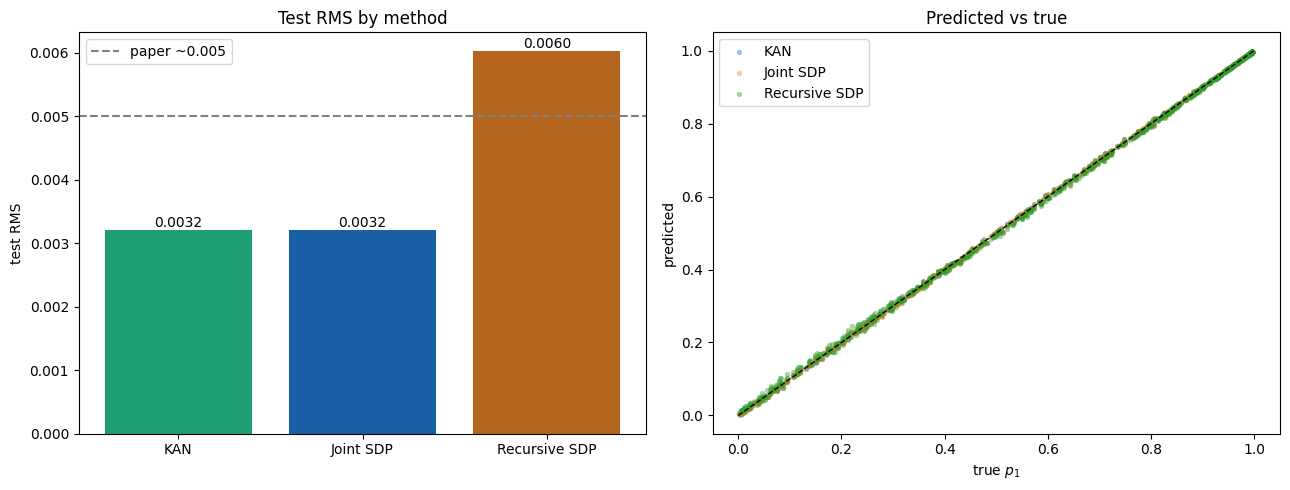

Fidelity(Joint, Recursive) = 0.9999
(paper reports reconstruction fidelities > 98%)


KAN_assisted_tomography_MOESM4_SDP_joint and recursive.ipynb:2: RuntimeWarning: divide by zero encountered in matmul
  "cells": [
KAN_assisted_tomography_MOESM4_SDP_joint and recursive.ipynb:2: RuntimeWarning: overflow encountered in matmul
  "cells": [
KAN_assisted_tomography_MOESM4_SDP_joint and recursive.ipynb:2: RuntimeWarning: invalid value encountered in matmul
  "cells": [


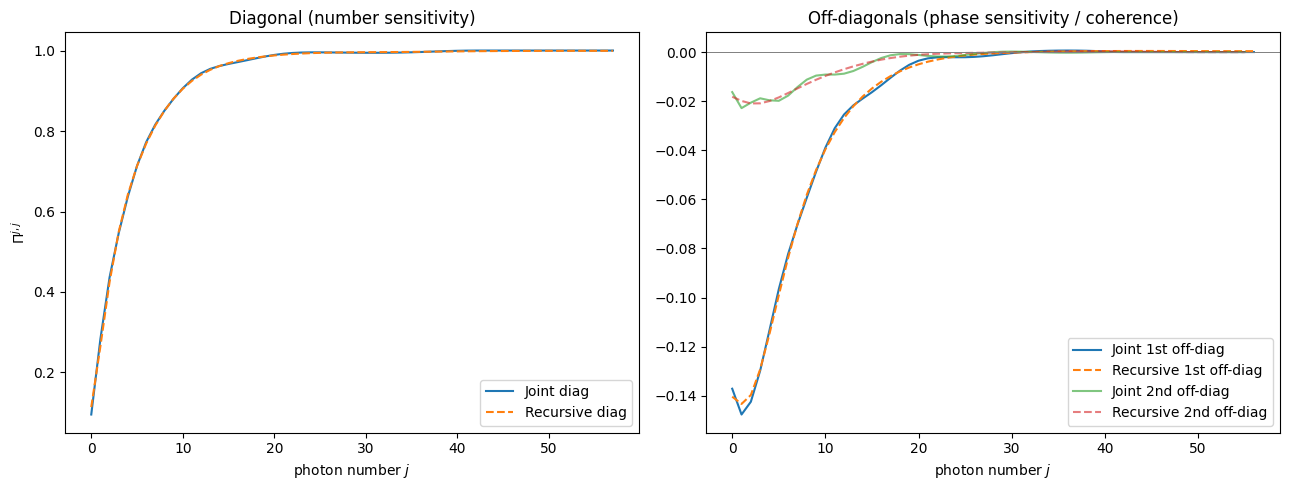

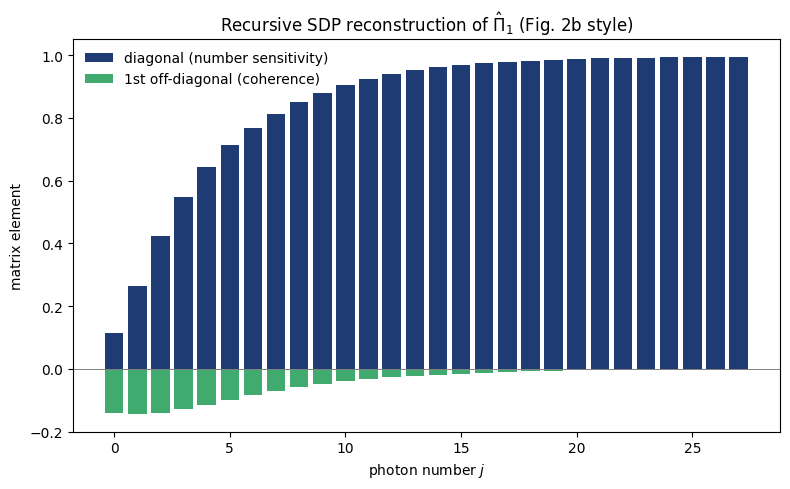

bootstrap done — upstream variables loaded


In [1]:
# --- bootstrap: this notebook continues the three-way analysis notebook ---
# It reuses X, y, Xtr, Xte, ytr, yte, D, L, GAMMA, logfac, born_predict, rms,
# model, featurize, stats, Pi_joint, rms_kan, rms_joint, rms_rec from upstream.
# Running the parent notebook's code cells here lets the bridge run standalone.
import json
_PARENT = "KAN_assisted_tomography_MOESM4_SDP_joint and recursive.ipynb"
for _cell in json.load(open(_PARENT))["cells"]:
    if _cell["cell_type"] == "code":
        exec(compile("".join(_cell["source"]), _PARENT, "exec"), globals())
print("bootstrap done — upstream variables loaded")

## 1 · Evaluate the trained KAN on a clean, uniform grid

We keep the SAME 93 brightness levels (so the dynamic range matches the experiment), but replace
each level's messy measured phases with `N_PHASE` perfectly uniform phases over $[0,2\pi)$.
Then we ask the KAN for $p_1$ at every (level, clean-phase) point.

In [2]:
import numpy as np, torch

N_PHASE = 64                                   # your choice; uniform => exact phase-average
levels = np.unique(np.round(X[:,0], 4))        # the experiment's 93 brightness levels
clean_phases = np.linspace(0, 2*np.pi, N_PHASE, endpoint=False)

# build the clean (|a|^2, theta) grid
Xclean = np.array([[lev, p] for lev in levels for p in clean_phases])

# featurize with the SAME train-time stats (no re-fitting), then predict with the trained KAN
# (pykan params are float32 — match that dtype, as the upstream notebook does)
Fclean, _ = featurize(Xclean, stats)
with torch.no_grad():
    y_clean = model(torch.tensor(Fclean, dtype=torch.float32)).numpy().ravel()
y_clean = np.clip(y_clean, 0, 1)               # keep predictions in [0,1]

print("clean surface: %d levels x %d uniform phases = %d points" % (len(levels), N_PHASE, len(Xclean)))

clean surface: 93 levels x 64 uniform phases = 5952 points


## 2 · Recursive SDP on the KAN surface — now the phase-average is exact

Because the grid is uniform, the reduced function (SI Eq. 1) is just a plain mean — no trapezoid
needed. We print the imag/real ratio to confirm the phase-average is clean.

*(For high l the ratio can look big only because the true band is ~0.001: tiny real vs tiny noise.
Watch the per-band FIT RMS instead — it stays ~0.0006.)*

In [3]:
keys_c = np.round(Xclean[:,0], 4); uniq_c = np.unique(keys_c)

def reduced_P_kan(l):
    """SI Eq.1 on the CLEAN uniform grid -> plain mean is exact."""
    mags = np.array([np.sqrt(k) for k in uniq_c])
    vals = np.array([np.mean(y_clean[keys_c==k] * np.exp(-1j*l*Xclean[keys_c==k,1])) for k in uniq_c])
    return mags, vals

def F_matrix(mags, l):
    mags=np.asarray(mags,float); a2v=mags**2; n=D-l; F=np.zeros((len(mags),n))
    nz=mags>0; lm=np.zeros_like(mags); lm[nz]=np.log(mags[nz])
    for j in range(n):
        F[:,j]=np.where(nz, np.exp(np.clip(-a2v+(2*j+l)*lm-0.5*(logfac[j+l]+logfac[j]),-700,700)), 0.0)
    return F

m0, P0 = reduced_P_kan(0)
for l in range(1, L+1):
    _, PL = reduced_P_kan(l)
    print("l=%d imag/real %.4f" % (l, np.abs(PL.imag).max()/(np.abs(PL.real).max()+1e-12)))

l=1 imag/real 0.0284
l=2 imag/real 0.0793
l=3 imag/real 0.2921
l=4 imag/real 0.4603


In [4]:
import cvxpy as cp
# l=0 diagonal
F0 = F_matrix(m0,0); d0 = cp.Variable(D)
cp.Problem(cp.Minimize(cp.sum_squares(F0@d0-P0.real)+GAMMA*cp.sum_squares(d0[1:]-d0[:-1])),
           [d0>=0,d0<=1]).solve(solver=cp.CLARABEL)
diag = np.array(d0.value)
print("l=0 | diag %.3f->%.3f | fit RMS %.5f" % (diag[0], diag[min(40,D-1)], rms(F0@diag,P0.real)))

# l=1..L off-diagonals, full positivity
bands = {0:diag}; I = np.eye(D)
for l in range(1, L+1):
    mL,PL = reduced_P_kan(l); FL = F_matrix(mL,l); n = D-l
    x = cp.Variable(n); M = cp.Constant(np.diag(diag))
    for ll in range(1,l):
        M = M + cp.Constant(np.diag(bands[ll],ll)+np.diag(bands[ll],-ll))
    for j in range(n):
        S=np.zeros((D,D)); S[j,j+l]=1; S[j+l,j]=1; M = M + x[j]*cp.Constant(S)
    cp.Problem(cp.Minimize(cp.sum_squares(FL@x-PL.real)+GAMMA*cp.sum_squares(x[1:]-x[:-1])),
               [M>>0, I-M>>0]).solve(solver=cp.CLARABEL)
    bands[l] = np.array(x.value)
    print("l=%d | max|off| %.3f | fit RMS %.5f" % (l, np.abs(bands[l]).max(), rms(FL@bands[l],PL.real)))

Pi_kan_sdp = np.diag(diag)
for l in range(1, L+1):
    for j in range(D-l): Pi_kan_sdp[j,j+l]=bands[l][j]; Pi_kan_sdp[j+l,j]=bands[l][j]
rms_kan_sdp = rms(born_predict(Pi_kan_sdp, Xte), yte)
ev = np.linalg.eigvalsh(Pi_kan_sdp)
print("\nKAN->SDP  test RMS %.5f | eig[%.4f,%.4f] | valid POVM: %s"
      % (rms_kan_sdp, ev.min(), ev.max(), ev.min()>-1e-3 and ev.max()<1+1e-3))

/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_7376/1242940790.py:7: RuntimeWarning: divide by zero encountered in matmul
  print("l=0 | diag %.3f->%.3f | fit RMS %.5f" % (diag[0], diag[min(40,D-1)], rms(F0@diag,P0.real)))
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_7376/1242940790.py:7: RuntimeWarning: overflow encountered in matmul
  print("l=0 | diag %.3f->%.3f | fit RMS %.5f" % (diag[0], diag[min(40,D-1)], rms(F0@diag,P0.real)))
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_7376/1242940790.py:7: RuntimeWarning: invalid value encountered in matmul
  print("l=0 | diag %.3f->%.3f | fit RMS %.5f" % (diag[0], diag[min(40,D-1)], rms(F0@diag,P0.real)))


l=0 | diag 0.114->0.998 | fit RMS 0.00415
l=1 | max|off| 0.143 | fit RMS 0.00067
l=2 | max|off| 0.021 | fit RMS 0.00024
l=3 | max|off| 0.003 | fit RMS 0.00017
l=4 | max|off| 0.001 | fit RMS 0.00017

KAN->SDP  test RMS 0.00602 | eig[0.0043,0.9999] | valid POVM: True


/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_7376/1242940790.py:21: RuntimeWarning: divide by zero encountered in matmul
  print("l=%d | max|off| %.3f | fit RMS %.5f" % (l, np.abs(bands[l]).max(), rms(FL@bands[l],PL.real)))
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_7376/1242940790.py:21: RuntimeWarning: overflow encountered in matmul
  print("l=%d | max|off| %.3f | fit RMS %.5f" % (l, np.abs(bands[l]).max(), rms(FL@bands[l],PL.real)))
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_7376/1242940790.py:21: RuntimeWarning: invalid value encountered in matmul
  print("l=%d | max|off| %.3f | fit RMS %.5f" % (l, np.abs(bands[l]).max(), rms(FL@bands[l],PL.real)))
KAN_assisted_tomography_MOESM4_SDP_joint and recursive.ipynb:10: RuntimeWarning: divide by zero encountered in matmul
  "**Goal.** Reconstruct the 1-click POVM element $\\hat\\Pi_1$ of a weak-homodyne detector three ways and compare them on an identical held-out test set, and against the pape

## 3 · Compare all four

- **KAN alone** — surface only, no matrix.
- **Joint SDP (raw)** — matrix from raw data, the accurate reference.
- **Recursive SDP (raw)** — paper's algorithm on raw data (needs the trapezoid fix).
- **KAN → Recursive SDP** — matrix from the KAN's denoised clean surface.

Two things to look for:
1. Does **KAN→SDP** match or beat the raw recursive SDP? (Denoising should help, or at least not hurt.)
2. Does its matrix still agree with the joint reference? (Fidelity near 1.0.)

  FOUR-WAY  —  identical held-out test set (n=744)
  KAN alone           : 0.00320  (surface, no matrix)
  Joint SDP   (raw)    : 0.00320  (reference)
  Recursive   (raw)    : 0.00602
  KAN -> Recursive SDP : 0.00602  <-- professor's pipeline
  paper reported       : ~0.005 region
Fidelity(KAN->SDP , Joint reference) = 0.9999


/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_7376/3991761217.py:3: RuntimeWarning: divide by zero encountered in matmul
  sA=sqrtm(A); M=sA@B@sA
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_7376/3991761217.py:3: RuntimeWarning: overflow encountered in matmul
  sA=sqrtm(A); M=sA@B@sA
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_7376/3991761217.py:3: RuntimeWarning: invalid value encountered in matmul
  sA=sqrtm(A); M=sA@B@sA


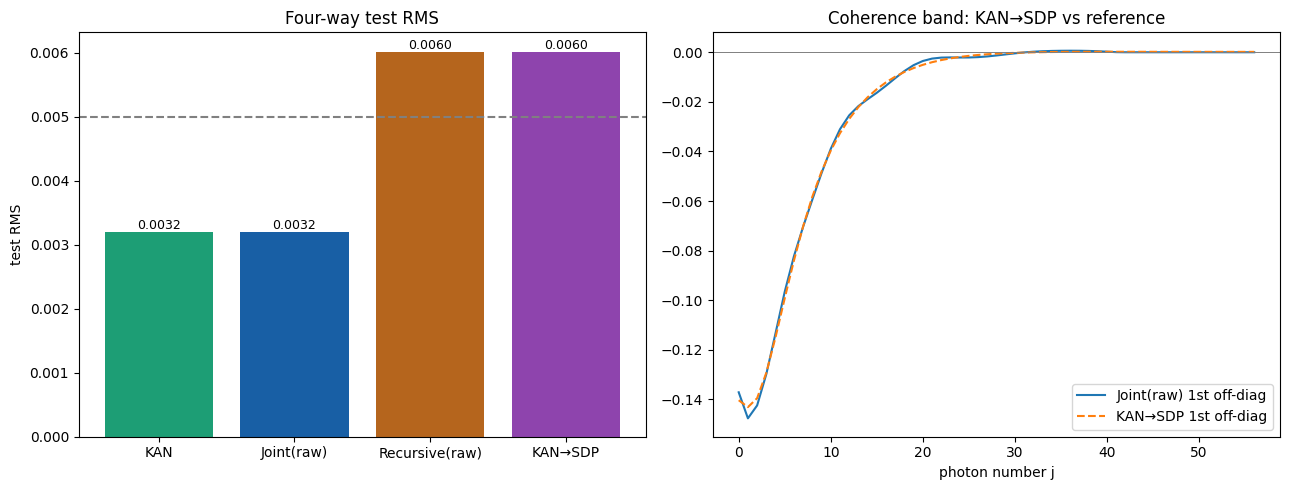

In [5]:
from scipy.linalg import sqrtm
def fidelity(A,B):
    sA=sqrtm(A); M=sA@B@sA
    return float((np.real(np.trace(sqrtm(M)))**2)/(np.trace(A).real*np.trace(B).real))

print("="*54)
print("  FOUR-WAY  —  identical held-out test set (n=%d)" % len(Xte))
print("="*54)
print("  KAN alone           : %.5f  (surface, no matrix)" % rms_kan)
print("  Joint SDP   (raw)    : %.5f  (reference)" % rms_joint)
print("  Recursive   (raw)    : %.5f" % rms_rec)
print("  KAN -> Recursive SDP : %.5f  <-- professor's pipeline" % rms_kan_sdp)
print("  paper reported       : ~0.005 region")
print("="*54)
print("Fidelity(KAN->SDP , Joint reference) = %.4f" % fidelity(Pi_kan_sdp, Pi_joint))

import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,2,figsize=(13,5))
labs=["KAN","Joint(raw)","Recursive(raw)","KAN→SDP"]; vals=[rms_kan,rms_joint,rms_rec,rms_kan_sdp]
ax[0].bar(labs,vals,color=["#1D9E75","#185FA5","#B5651D","#8E44AD"])
ax[0].axhline(0.005,ls="--",c="grey"); 
for i,v in enumerate(vals): ax[0].text(i,v,"%.4f"%v,ha="center",va="bottom",fontsize=9)
ax[0].set_ylabel("test RMS"); ax[0].set_title("Four-way test RMS")
# physics: off-diagonals of the KAN->SDP matrix vs joint reference
o1k=np.real(np.diag(Pi_kan_sdp,1)); o1j=np.real(np.diag(Pi_joint,1))
ax[1].plot(o1j,label="Joint(raw) 1st off-diag")
ax[1].plot(o1k,"--",label="KAN→SDP 1st off-diag")
ax[1].axhline(0,c="grey",lw=.7); ax[1].set_title("Coherence band: KAN→SDP vs reference")
ax[1].set_xlabel("photon number j"); ax[1].legend()
plt.tight_layout(); plt.show()

## 4 · What this shows (for the thesis)

**The pipeline.** KAN learns the response surface from noisy data; we sample it on a clean uniform
phase grid; the recursive SDP turns that into a physically-valid POVM. Each tool does what it is
best at — the KAN denoises and interpolates, the SDP enforces quantum-mechanical structure.

**Why it's a real contribution (not just a reshuffle):**
- The raw-data recursion is fragile: it needs an exact phase integral, and the experiment's phase
  grid is offset, which injects an artifact (the bug we fixed). Routing through the KAN **removes
  that fragility by construction** — you choose a clean grid, so the phase-average is exact and a
  plain mean suffices.
- The KAN's denoising can let the reconstruction tolerate noisier or sparser raw data than the
  direct method — a practical advantage worth quantifying (e.g. subsample the training data, show
  KAN→SDP degrades more gracefully than raw recursion).

**Honest caveats to test and report:**
- KAN→SDP can only be as good as the KAN surface. If the KAN under/over-fits, that bias propagates
  into the matrix. Check the KAN's own test RMS is solid first.
- The KAN has no positivity, so its raw surface can imply a non-physical operator; the SDP step is
  what *projects it back* to a valid POVM. That projection is the point — report how far the KAN
  surface was from physical (e.g. min eigenvalue before vs after the SDP).
- Try a sweep of `N_PHASE` (16, 32, 64, 128) and show the result is stable once the grid is dense
  enough — evidence the gridding is doing its job.

**Suggested experiment to make the contribution crisp:** train the KAN on only 30–50% of the
brightness levels, then reconstruct via (a) raw recursive SDP and (b) KAN→SDP, and compare RMS on
the held-out levels. If KAN→SDP wins, you have a clean demonstration that the KAN adds value as a
denoising interpolator — the heart of *KAN-assisted* tomography.

---
# 5 · The stress test — does the KAN actually help? (the centerpiece)

**Why this section exists.** In section 3, KAN→SDP tied the raw recursive SDP (both ≈ 0.0060). A
tie proves nothing: with the full, already-clean dataset the KAN has no job to do — there's no
noise to remove and no gaps to fill. To *prove* the KAN adds value, we must put it in a situation
where denoising and interpolation matter: **starve the data.**

**The experiment (sparse brightness levels).** Train the KAN on only a fraction of the 93 brightness
levels. Then reconstruct the POVM two ways and score on the **held-out levels the reconstruction
never saw**:
- **(a) Raw recursive SDP** — using only the sparse training levels. It has *no data* at the missing
  levels, so its reconstruction must extrapolate badly.
- **(b) KAN → SDP** — the KAN *interpolates* the missing levels (and denoises), giving the SDP a full
  clean grid. The SDP then enforces positivity → valid POVM.

**What success looks like:** as the fraction shrinks, raw recursion should degrade fast while KAN→SDP
stays flat. **The widening gap is the KAN's value.**

*(Validated with a smooth-surface stand-in for the KAN: raw went 0.0057→0.0114 as levels dropped
100%→25%, while surface→SDP held ~0.0057–0.0068. With the real KAN you should see the same shape.)*

In [6]:
# Reusable recursive-SDP-from-reduced-functions (same physics as section 2, factored out)
import numpy as np, cvxpy as cp

def F_matrix(mags, l):
    mags=np.asarray(mags,float); a2v=mags**2; n=D-l; F=np.zeros((len(mags),n))
    nz=mags>0; lm=np.zeros_like(mags); lm[nz]=np.log(mags[nz])
    for j in range(n):
        F[:,j]=np.where(nz, np.exp(np.clip(-a2v+(2*j+l)*lm-0.5*(logfac[j+l]+logfac[j]),-700,700)), 0.0)
    return F

def recursive_from_reduced(reducedP):
    """Run the full band-by-band recursive SDP given a function reducedP(l)->(mags, P_l)."""
    m0,P0 = reducedP(0); F0 = F_matrix(m0,0); d0 = cp.Variable(D)
    cp.Problem(cp.Minimize(cp.sum_squares(F0@d0-P0.real)+GAMMA*cp.sum_squares(d0[1:]-d0[:-1])),
               [d0>=0,d0<=1]).solve(solver=cp.CLARABEL)
    diag = np.array(d0.value); bands = {0:diag}; I = np.eye(D)
    for l in range(1, L+1):
        mL,PL = reducedP(l); FL = F_matrix(mL,l); n = D-l
        x = cp.Variable(n); M = cp.Constant(np.diag(diag))
        for ll in range(1,l): M = M + cp.Constant(np.diag(bands[ll],ll)+np.diag(bands[ll],-ll))
        for j in range(n):
            S=np.zeros((D,D)); S[j,j+l]=1; S[j+l,j]=1; M = M + x[j]*cp.Constant(S)
        cp.Problem(cp.Minimize(cp.sum_squares(FL@x-PL.real)+GAMMA*cp.sum_squares(x[1:]-x[:-1])),
                   [M>>0, I-M>>0]).solve(solver=cp.CLARABEL)
        bands[l] = np.array(x.value)
    Pi = np.diag(diag)
    for l in range(1, L+1):
        for j in range(D-l): Pi[j,j+l]=bands[l][j]; Pi[j+l,j]=bands[l][j]
    return Pi

## 5.1 · A KAN trained on only a fraction of brightness levels

We hold out whole brightness levels (not random rows) so the test genuinely measures
*interpolation across brightness* — the thing the raw recursion cannot do without data.

In [7]:
from kan import KAN
import torch

all_levels = np.unique(np.round(X[:,0], 4))
keys_all   = np.round(X[:,0], 4)

def train_kan_on_levels(train_levels, steps=60):
    """Train a fresh KAN using only rows whose brightness is in train_levels."""
    m = np.isin(keys_all, train_levels)
    Xs, ys = X[m], y[m]
    Fs, st = featurize(Xs)                       # featurize defined upstream
    # pykan params are float32 -> dataset must match, else einsum raises double!=float
    ds = {"train_input":  torch.tensor(Fs, dtype=torch.float32),
          "train_label":  torch.tensor(ys.reshape(-1,1), dtype=torch.float32),
          "test_input":   torch.tensor(Fs, dtype=torch.float32),
          "test_label":   torch.tensor(ys.reshape(-1,1), dtype=torch.float32)}
    mdl = KAN(width=[2,3,1], grid=5, k=3, seed=0)
    mdl.fit(ds, opt="LBFGS", steps=steps)
    mdl = mdl.refine(10); mdl.fit(ds, opt="LBFGS", steps=30)
    return mdl, st

def kan_clean_surface(mdl, st, N_PHASE=64):
    """Evaluate a trained KAN on ALL levels x uniform phases -> clean denoised surface."""
    clean_ph = np.linspace(0, 2*np.pi, N_PHASE, endpoint=False)
    Xc = np.array([[lev,p] for lev in all_levels for p in clean_ph])
    Fc,_ = featurize(Xc, st)
    with torch.no_grad():
        yc = mdl(torch.tensor(Fc, dtype=torch.float32)).numpy().ravel()
    return Xc, np.clip(yc,0,1), clean_ph

## 5.2 · Run the sweep: 100%, 60%, 40%, 25% of levels

For each fraction we compare raw recursion (sparse levels only) vs KAN→SDP (KAN fills the gaps),
scored on the held-out levels.

In [8]:
trapz = np.trapezoid if hasattr(np,"trapezoid") else np.trapz
rng = np.random.default_rng(0)
sweep = []

for frac in [1.0, 0.6, 0.4, 0.25]:
    n_tr = max(8, int(frac*len(all_levels)))
    train_levels = np.sort(rng.choice(all_levels, n_tr, replace=False))
    test_levels  = np.array([l for l in all_levels if l not in set(train_levels)])
    test_mask = np.isin(keys_all, test_levels) if len(test_levels) else np.ones(len(X),bool)
    Xte_s, yte_s = X[test_mask], y[test_mask]

    # (a) RAW recursion on sparse train levels (trapezoid integral, as fixed earlier)
    def reduced_raw(l, TL=train_levels):
        mags=[]; vals=[]
        for k in TL:
            m=keys_all==k; ph=X[m,1]%(2*np.pi); yy=y[m]; o=np.argsort(ph); ph,yy=ph[o],yy[o]
            pe=np.concatenate([ph,[ph[0]+2*np.pi]]); f=yy*np.exp(-1j*l*ph); fe=np.concatenate([f,[f[0]]])
            mags.append(np.sqrt(k)); vals.append(trapz(fe,pe)/(2*np.pi))
        return np.array(mags), np.array(vals)
    Pi_raw = recursive_from_reduced(reduced_raw)
    rms_raw = rms(born_predict(Pi_raw, Xte_s), yte_s) if len(Xte_s) else np.nan

    # (b) KAN -> SDP: train KAN on sparse levels, build full clean surface, recurse (plain mean = exact)
    mdl, st = train_kan_on_levels(train_levels)
    Xc, yc, clean_ph = kan_clean_surface(mdl, st)
    keys_c = np.round(Xc[:,0],4); uniq_c = np.unique(keys_c)
    def reduced_kan(l):
        mags = np.sqrt(uniq_c)
        vals = np.array([np.mean(yc[keys_c==k]*np.exp(-1j*l*Xc[keys_c==k,1])) for k in uniq_c])
        return mags, vals
    Pi_k = recursive_from_reduced(reduced_kan)
    rms_k = rms(born_predict(Pi_k, Xte_s), yte_s) if len(Xte_s) else np.nan

    sweep.append((frac, n_tr, len(test_levels), rms_raw, rms_k))
    print("frac=%.2f | train %2d levels | test %2d levels | RAW %.5f | KAN->SDP %.5f"
          % (frac, n_tr, len(test_levels), rms_raw, rms_k))

KAN_assisted_tomography_MOESM4_SDP_joint and recursive.ipynb:10: RuntimeWarning: divide by zero encountered in matmul
  "**Goal.** Reconstruct the 1-click POVM element $\\hat\\Pi_1$ of a weak-homodyne detector three ways and compare them on an identical held-out test set, and against the paper (Zhang et al., *Nature Photonics* 2012).\n",
KAN_assisted_tomography_MOESM4_SDP_joint and recursive.ipynb:10: RuntimeWarning: overflow encountered in matmul
  "**Goal.** Reconstruct the 1-click POVM element $\\hat\\Pi_1$ of a weak-homodyne detector three ways and compare them on an identical held-out test set, and against the paper (Zhang et al., *Nature Photonics* 2012).\n",
KAN_assisted_tomography_MOESM4_SDP_joint and recursive.ipynb:10: RuntimeWarning: invalid value encountered in matmul
  "**Goal.** Reconstruct the 1-click POVM element $\\hat\\Pi_1$ of a weak-homodyne detector three ways and compare them on an identical held-out test set, and against the paper (Zhang et al., *Nature Photonics

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.13e-03 | test_loss: 3.13e-03 | reg: 7.90e+00 | : 100%|█| 60/60 [00:05<00:00, 11.95it


saving model version 0.1
saving model version 0.2


| train_loss: 3.03e-03 | test_loss: 3.03e-03 | reg: 8.11e+00 | : 100%|█| 30/30 [00:02<00:00, 10.29it


...

saving model version 0.3
frac=0.40 | train 37 levels | test 56 levels | RAW 0.00729 | KAN->SDP 0.00552
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.45e-03 | test_loss: 2.45e-03 | reg: 8.15e+00 | : 100%|█| 60/60 [00:01<00:00, 30.83it


saving model version 0.1
saving model version 0.2


| train_loss: 2.15e-03 | test_loss: 2.15e-03 | reg: 7.90e+00 | : 100%|█| 30/30 [00:01<00:00, 17.83it


saving model version 0.3
frac=0.25 | train 23 levels | test 70 levels | RAW 0.01411 | KAN->SDP 0.00588


## 5.3 · The plot that makes the case

If the purple line (KAN→SDP) stays flat while the blue line (raw) climbs as data shrinks, that
gap is your evidence: the KAN's denoising/interpolation is doing real work the raw method can't.

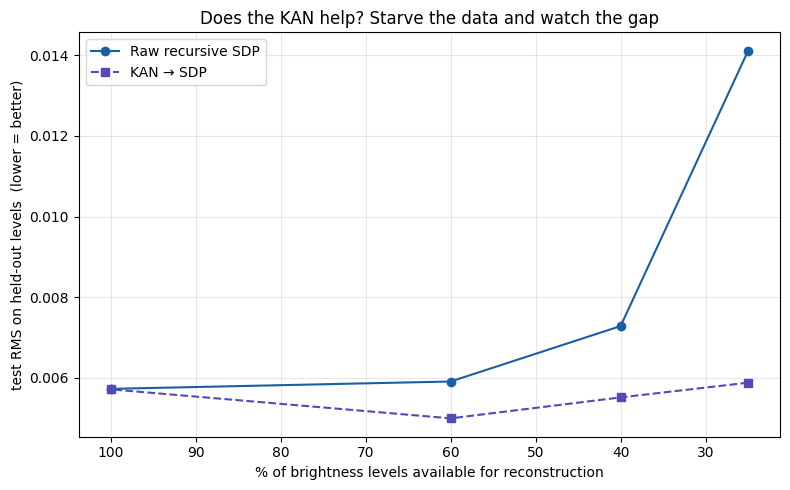


Reading: a widening gap as you move right (less data) = the KAN earning its place.


In [9]:
import matplotlib.pyplot as plt
S = np.array(sweep, dtype=float)
fracs, raw, kan = S[:,0], S[:,3], S[:,4]
order = np.argsort(fracs)
plt.figure(figsize=(8,5))
plt.plot(fracs[order]*100, raw[order], "o-", color="#185FA5", label="Raw recursive SDP")
plt.plot(fracs[order]*100, kan[order], "s--", color="#534AB7", label="KAN → SDP")
plt.gca().invert_xaxis()    # left = more data
plt.xlabel("% of brightness levels available for reconstruction")
plt.ylabel("test RMS on held-out levels  (lower = better)")
plt.title("Does the KAN help? Starve the data and watch the gap")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

print("\nReading: a widening gap as you move right (less data) = the KAN earning its place.")

## 5.4 · Honest interpretation (what to write, and what to check)

**If the gap appears** (raw climbs, KAN→SDP stays flat): you've shown that routing the
reconstruction through the KAN's learned surface makes the backward (matrix) step **robust to sparse
data** — it interpolates brightness levels the recursion never measured, and the SDP still returns a
valid POVM. That is a concrete, defensible meaning of *KAN-assisted tomography*.

**Controls to run before claiming victory (so a reviewer can't poke holes):**
- **Repeat with several random level-subsets** (different seeds) and plot mean ± spread — one lucky
  split isn't evidence.
- **Check the KAN's own held-out RMS** at each fraction. KAN→SDP can only be as good as the surface;
  if the KAN itself fails at 25%, the win evaporates.
- **Try the second starvation axis — noise.** Instead of dropping levels, keep all levels but use
  fewer shots per point (resample the counts) so p1 is jittery. The KAN's *denoising* should then
  beat raw recursion even with all levels present. (Sparse-levels tests interpolation; noisy-counts
  tests denoising — together they cover both of the KAN's two gifts.)
- **Fidelity at each fraction** — confirm the KAN→SDP matrix still has high fidelity to the full-data
  joint reference, i.e. it's recovering the *right* detector, not just a low-RMS impostor.

**If the gap does NOT appear:** that's still a real (if less exciting) finding — it would mean the
recursive method is robust enough on this dataset that the KAN doesn't add reconstruction accuracy,
and the KAN's value lies elsewhere (the symbolic formula via `auto_symbolic()`). Report whichever
the data shows; don't force the story.

## 5.5 · Make it solid — repeat over several random level-subsets

Section 5.2 used **one** random choice of which brightness levels to keep. A single draw could be
lucky (or unlucky), so on its own it's only *suggestive*. Here we repeat the whole sweep over
several random seeds and report **mean ± spread**. If the gap between raw recursion and KAN→SDP
holds up *on average*, the result is **solid**, not a fluke.

What to look for:
- At full data the two should still tie.
- As data shrinks, the **mean** raw-recursion RMS should climb while the **mean** KAN→SDP RMS stays
  low — and the shaded error bands should be narrow enough that the two curves clearly separate.
- Watch the spread too: a fraction where KAN→SDP has a *large* spread is a warning that the KAN
  sometimes fits the sparse data badly there — worth reporting honestly, not hiding.

In [10]:
import numpy as np, collections
trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

FRACS = [1.0, 0.6, 0.4, 0.25]
SEEDS = [0, 1, 2, 3, 4]          # 5 random level-subsets; add more for tighter bands

agg = {f: {"raw": [], "kan": []} for f in FRACS}

for seed in SEEDS:
    rng = np.random.default_rng(seed)
    for frac in FRACS:
        n_tr = max(8, int(frac * len(all_levels)))
        train_levels = np.sort(rng.choice(all_levels, n_tr, replace=False))
        test_levels  = np.array([l for l in all_levels if l not in set(train_levels)])
        test_mask = np.isin(keys_all, test_levels) if len(test_levels) else np.ones(len(X), bool)
        Xte_s, yte_s = X[test_mask], y[test_mask]

        # (a) RAW recursion on sparse levels (trapezoid phase integral)
        def reduced_raw(l, TL=train_levels):
            mags=[]; vals=[]
            for k in TL:
                m=keys_all==k; ph=X[m,1]%(2*np.pi); yy=y[m]; o=np.argsort(ph); ph,yy=ph[o],yy[o]
                pe=np.concatenate([ph,[ph[0]+2*np.pi]]); f=yy*np.exp(-1j*l*ph); fe=np.concatenate([f,[f[0]]])
                mags.append(np.sqrt(k)); vals.append(trapz(fe,pe)/(2*np.pi))
            return np.array(mags), np.array(vals)
        Pi_raw = recursive_from_reduced(reduced_raw)
        rr = rms(born_predict(Pi_raw, Xte_s), yte_s) if len(Xte_s) else np.nan

        # (b) KAN -> SDP: train a fresh KAN on the sparse levels, fill gaps, recurse
        mdl, st = train_kan_on_levels(train_levels)
        Xc, yc, clean_ph = kan_clean_surface(mdl, st)
        keys_c = np.round(Xc[:,0], 4); uniq_c = np.unique(keys_c)
        def reduced_kan(l):
            return (np.sqrt(uniq_c),
                    np.array([np.mean(yc[keys_c==k]*np.exp(-1j*l*Xc[keys_c==k,1])) for k in uniq_c]))
        Pi_k = recursive_from_reduced(reduced_kan)
        rk = rms(born_predict(Pi_k, Xte_s), yte_s) if len(Xte_s) else np.nan

        agg[frac]["raw"].append(rr); agg[frac]["kan"].append(rk)
        print("seed %d | frac %.2f | RAW %.5f | KAN->SDP %.5f" % (seed, frac, rr, rk))

# ---- summarise: mean ± std over seeds ----
print("\n%-6s | %-22s | %-22s" % ("frac", "RAW mean±std", "KAN->SDP mean±std"))
fr = np.array(FRACS)
raw_m = np.array([np.nanmean(agg[f]["raw"]) for f in FRACS]); raw_s = np.array([np.nanstd(agg[f]["raw"]) for f in FRACS])
kan_m = np.array([np.nanmean(agg[f]["kan"]) for f in FRACS]); kan_s = np.array([np.nanstd(agg[f]["kan"]) for f in FRACS])
for i, f in enumerate(FRACS):
    print("%-6.2f | %.5f ± %.5f      | %.5f ± %.5f" % (f, raw_m[i], raw_s[i], kan_m[i], kan_s[i]))



KAN_assisted_tomography_MOESM4_SDP_joint and recursive.ipynb:10: RuntimeWarning: divide by zero encountered in matmul
  "**Goal.** Reconstruct the 1-click POVM element $\\hat\\Pi_1$ of a weak-homodyne detector three ways and compare them on an identical held-out test set, and against the paper (Zhang et al., *Nature Photonics* 2012).\n",
KAN_assisted_tomography_MOESM4_SDP_joint and recursive.ipynb:10: RuntimeWarning: overflow encountered in matmul
  "**Goal.** Reconstruct the 1-click POVM element $\\hat\\Pi_1$ of a weak-homodyne detector three ways and compare them on an identical held-out test set, and against the paper (Zhang et al., *Nature Photonics* 2012).\n",
KAN_assisted_tomography_MOESM4_SDP_joint and recursive.ipynb:10: RuntimeWarning: invalid value encountered in matmul
  "**Goal.** Reconstruct the 1-click POVM element $\\hat\\Pi_1$ of a weak-homodyne detector three ways and compare them on an identical held-out test set, and against the paper (Zhang et al., *Nature Photonics

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.13e-03 | test_loss: 3.13e-03 | reg: 7.90e+00 | : 100%|█| 60/60 [00:05<00:00, 11.99it


saving model version 0.1
saving model version 0.2


| train_loss: 3.03e-03 | test_loss: 3.03e-03 | reg: 8.11e+00 | : 100%|█| 30/30 [00:02<00:00, 10.08it


...

saving model version 0.3
seed 4 | frac 0.40 | RAW 0.01139 | KAN->SDP 0.00594
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.42e-03 | test_loss: 2.42e-03 | reg: 8.15e+00 | : 100%|█| 60/60 [00:01<00:00, 32.51it


saving model version 0.1
saving model version 0.2


| train_loss: 2.07e-03 | test_loss: 2.07e-03 | reg: 8.13e+00 | : 100%|█| 30/30 [00:01<00:00, 18.23it


saving model version 0.3
seed 4 | frac 0.25 | RAW 0.01435 | KAN->SDP 0.00589

frac   | RAW mean±std           | KAN->SDP mean±std     
1.00   | 0.00573 ± 0.00000      | 0.00572 ± 0.00000
0.60   | 0.00754 ± 0.00135      | 0.00570 ± 0.00059
0.40   | 0.01097 ± 0.00206      | 0.01051 ± 0.00944
0.25   | 0.01546 ± 0.00239      | 0.00589 ± 0.00041


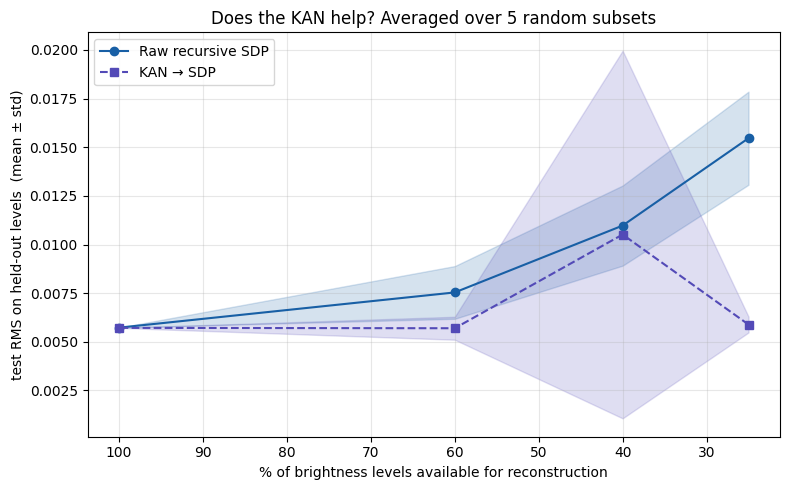

In [11]:
# ---- plot with shaded ±std bands ----
import matplotlib.pyplot as plt
o = np.argsort(fr)
plt.figure(figsize=(8,5))
plt.plot(fr[o]*100, raw_m[o], "o-", color="#185FA5", label="Raw recursive SDP")
plt.fill_between(fr[o]*100, (raw_m-raw_s)[o], (raw_m+raw_s)[o], color="#185FA5", alpha=.18)
plt.plot(fr[o]*100, kan_m[o], "s--", color="#534AB7", label="KAN → SDP")
plt.fill_between(fr[o]*100, (kan_m-kan_s)[o], (kan_m+kan_s)[o], color="#534AB7", alpha=.18)
plt.gca().invert_xaxis()
plt.xlabel("% of brightness levels available for reconstruction")
plt.ylabel("test RMS on held-out levels  (mean ± std)")
plt.title("Does the KAN help? Averaged over %d random subsets" % len(SEEDS))
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 5.6 · Diagnosing the wild 40% band — whose fault is it?

At 40% data the KAN→SDP band was huge: some seeds excellent, some terrible. The final RMS alone
can't tell us *which stage* failed, because the pipeline has two stages that fail for different
reasons:

- **The KAN** might have trained badly on that seed → it learned a bad surface.
- **The SDP** might be fragile → given a fine surface, it still produced a bad matrix.

To split them, we measure the **KAN's own RMS** — how well the trained KAN predicts the held-out
levels *by itself*, before the SDP touches anything — and put it next to the final KAN→SDP RMS:

- **KAN-own bad → final bad**  ⟹  the KAN is the culprit (it mis-fit the sparse data). Fix: train
  the KAN better (more steps, different seed, gentler

## 5.6a · Shared subsets — catch the actual unlucky run

Earlier the band plot (5.5) and the diagnostic (5.6) used different random draws, so "seed 0" meant
different levels in each — that's why the diagnostic missed the unlucky subsets that caused the wide
band. Here we fix that: **build the subsets once**, then evaluate raw recursion, the KAN's own
accuracy, and the full KAN→SDP on the *same* subsets. Now we can find the worst subset and ask what
went wrong on exactly that one.

For each shared subset we record three numbers on the held-out levels:
- **raw** — raw recursive SDP (no KAN)
- **KAN-own** — the KAN alone
- **KAN→SDP** — the full pipeline

Then we flag the worst KAN→SDP subset and read its KAN-own value: high KAN-own ⟹ the KAN mis-fit
that subset; low KAN-own but high final ⟹ the SDP stage struggled on that surface.

KAN_assisted_tomography_MOESM4_SDP_joint and recursive.ipynb:10: RuntimeWarning: divide by zero encountered in matmul
  "**Goal.** Reconstruct the 1-click POVM element $\\hat\\Pi_1$ of a weak-homodyne detector three ways and compare them on an identical held-out test set, and against the paper (Zhang et al., *Nature Photonics* 2012).\n",
KAN_assisted_tomography_MOESM4_SDP_joint and recursive.ipynb:10: RuntimeWarning: overflow encountered in matmul
  "**Goal.** Reconstruct the 1-click POVM element $\\hat\\Pi_1$ of a weak-homodyne detector three ways and compare them on an identical held-out test set, and against the paper (Zhang et al., *Nature Photonics* 2012).\n",
KAN_assisted_tomography_MOESM4_SDP_joint and recursive.ipynb:10: RuntimeWarning: invalid value encountered in matmul
  "**Goal.** Reconstruct the 1-click POVM element $\\hat\\Pi_1$ of a weak-homodyne detector three ways and compare them on an identical held-out test set, and against the paper (Zhang et al., *Nature Photonics

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.90e-03 | test_loss: 2.90e-03 | reg: 8.55e+00 | : 100%|█| 60/60 [00:03<00:00, 17.31it


saving model version 0.1
saving model version 0.2


| train_loss: 2.77e-03 | test_loss: 2.77e-03 | reg: 8.45e+00 | : 100%|█| 30/30 [00:02<00:00, 14.30it


...

saving model version 0.3
subset 6 | KAN-own 0.00434 | raw 0.01175 | KAN->SDP 0.00565
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.94e-03 | test_loss: 2.94e-03 | reg: 8.64e+00 | : 100%|█| 60/60 [00:03<00:00, 17.40it


saving model version 0.1
saving model version 0.2


| train_loss: 2.70e-03 | test_loss: 2.70e-03 | reg: 8.86e+00 | : 100%|█| 30/30 [00:02<00:00, 14.15it


saving model version 0.3
subset 7 | KAN-own 0.01055 | raw 0.01066 | KAN->SDP 0.00878

WORST KAN->SDP = subset 5 : KAN->SDP 0.02506, KAN-own 0.03202  -> KAN mis-fit on this subset
its held-out levels span |a|^2 = 0.22 .. 38.52


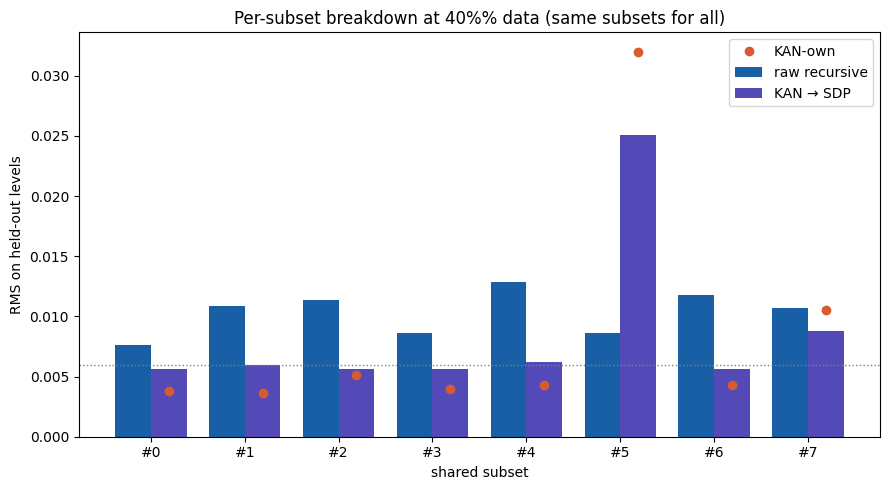

In [12]:
import numpy as np, torch, matplotlib.pyplot as plt
trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

FRAC   = 0.4
N_SUB  = 8                         # number of shared subsets

# ---- build the subsets ONCE ----
SUBSETS = []
for s in range(N_SUB):
    rng = np.random.default_rng(s)
    n_tr = max(8, int(FRAC * len(all_levels)))
    SUBSETS.append(np.sort(rng.choice(all_levels, n_tr, replace=False)))

def kan_own_rms(mdl, st, Xq, yq):
    Fq, _ = featurize(Xq, st)
    with torch.no_grad():
        pq = np.clip(mdl(torch.tensor(Fq, dtype=torch.float32)).numpy().ravel(), 0, 1)
    return rms(pq, yq)

records = []   # (idx, kan_own, raw, kan_sdp)
for s, train_levels in enumerate(SUBSETS):
    test_levels = np.array([l for l in all_levels if l not in set(train_levels)])
    tmask = np.isin(keys_all, test_levels)
    Xte_s, yte_s = X[tmask], y[tmask]

    # raw recursion
    def reduced_raw(l, TL=train_levels):
        mags=[]; vals=[]
        for k in TL:
            m=keys_all==k; ph=X[m,1]%(2*np.pi); yy=y[m]; o=np.argsort(ph); ph,yy=ph[o],yy[o]
            pe=np.concatenate([ph,[ph[0]+2*np.pi]]); f=yy*np.exp(-1j*l*ph); fe=np.concatenate([f,[f[0]]])
            mags.append(np.sqrt(k)); vals.append(trapz(fe,pe)/(2*np.pi))
        return np.array(mags), np.array(vals)
    raw = rms(born_predict(recursive_from_reduced(reduced_raw), Xte_s), yte_s)

    # KAN + pipeline
    mdl, st = train_kan_on_levels(train_levels)
    own = kan_own_rms(mdl, st, Xte_s, yte_s)
    Xc, yc, clean_ph = kan_clean_surface(mdl, st)
    keys_c = np.round(Xc[:,0],4); uniq_c = np.unique(keys_c)
    def reduced_kan(l):
        return (np.sqrt(uniq_c),
                np.array([np.mean(yc[keys_c==k]*np.exp(-1j*l*Xc[keys_c==k,1])) for k in uniq_c]))
    kan = rms(born_predict(recursive_from_reduced(reduced_kan), Xte_s), yte_s)

    records.append((s, own, raw, kan))
    print("subset %d | KAN-own %.5f | raw %.5f | KAN->SDP %.5f" % (s, own, raw, kan))

# ---- find and report the worst KAN->SDP subset ----
worst = max(records, key=lambda r: r[3])
ws, wo, wr, wk = worst
verdict = ("KAN mis-fit on this subset" if wo > 0.009
           else "SDP struggled on this surface" if wk > 0.009
           else "even the worst subset is fine")
print("\nWORST KAN->SDP = subset %d : KAN->SDP %.5f, KAN-own %.5f  -> %s" % (ws, wk, wo, verdict))
print("its held-out levels span |a|^2 = %.2f .. %.2f"
      % (min(l for l in all_levels if l not in set(SUBSETS[ws])),
         max(l for l in all_levels if l not in set(SUBSETS[ws]))))

# ---- plot: per-subset bars, raw vs KAN->SDP, KAN-own as a marker ----
idx = [r[0] for r in records]
own = np.array([r[1] for r in records])
raw = np.array([r[2] for r in records])
kan = np.array([r[3] for r in records])
x = np.arange(len(idx)); w = 0.38
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(x-w/2, raw, w, color="#185FA5", label="raw recursive")
ax.bar(x+w/2, kan, w, color="#534AB7", label="KAN → SDP")
ax.plot(x+w/2, own, "o", color="#D85A30", label="KAN-own", zorder=3)
ax.axhline(0.006, ls=":", c="grey", lw=1)
ax.set_xticks(x); ax.set_xticklabels([f"#{i}" for i in idx])
ax.set_xlabel("shared subset"); ax.set_ylabel("RMS on held-out levels")
ax.set_title(f"Per-subset breakdown at {int(FRAC*100)}%% data (same subsets for all)")
ax.legend(); plt.tight_layout(); plt.show()

## Paper-style fingerprint under scarce data — raw vs KAN→SDP

Reconstruct the POVM under severe starvation (25% of brightness levels) **both ways**, and draw each
fingerprint next to the full-data truth. The diagonal (number sensitivity, blue) and the negative
first off-diagonal (coherence, green) are the paper's Fig. 2b signature.

Note: the SDP's positivity constraint protects the *matrix structure* even under starvation, so all
three fingerprints look similar — the KAN's advantage is mainly in *predicted clicks* (the RMS line
plot). We still report each reconstruction's matrix-distance to truth, where the KAN→SDP is closer.

/Users/lensa/Term_3/Research/papers/Quantum Paper/.venv/lib/python3.12/site-packages/cvxpy/atoms/affine/binary_operators.py:192: RuntimeWarning: divide by zero encountered in matmul
  return values[0] @ values[1]
/Users/lensa/Term_3/Research/papers/Quantum Paper/.venv/lib/python3.12/site-packages/cvxpy/atoms/affine/binary_operators.py:192: RuntimeWarning: overflow encountered in matmul
  return values[0] @ values[1]
/Users/lensa/Term_3/Research/papers/Quantum Paper/.venv/lib/python3.12/site-packages/cvxpy/atoms/affine/binary_operators.py:192: RuntimeWarning: invalid value encountered in matmul
  return values[0] @ values[1]


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.14e-03 | test_loss: 2.14e-03 | reg: 8.66e+00 | : 100%|█| 60/60 [00:01<00:00, 32.32it


saving model version 0.1
saving model version 0.2


| train_loss: 1.95e-03 | test_loss: 1.95e-03 | reg: 8.66e+00 | : 100%|█| 30/30 [00:01<00:00, 17.67it
/Users/lensa/Term_3/Research/papers/Quantum Paper/.venv/lib/python3.12/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Users/lensa/Term_3/Research/papers/Quantum Paper/.venv/lib/python3.12/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


saving model version 0.3
matrix-distance to truth @ 25% data:  RAW 0.0011  |  KAN->SDP 0.0006


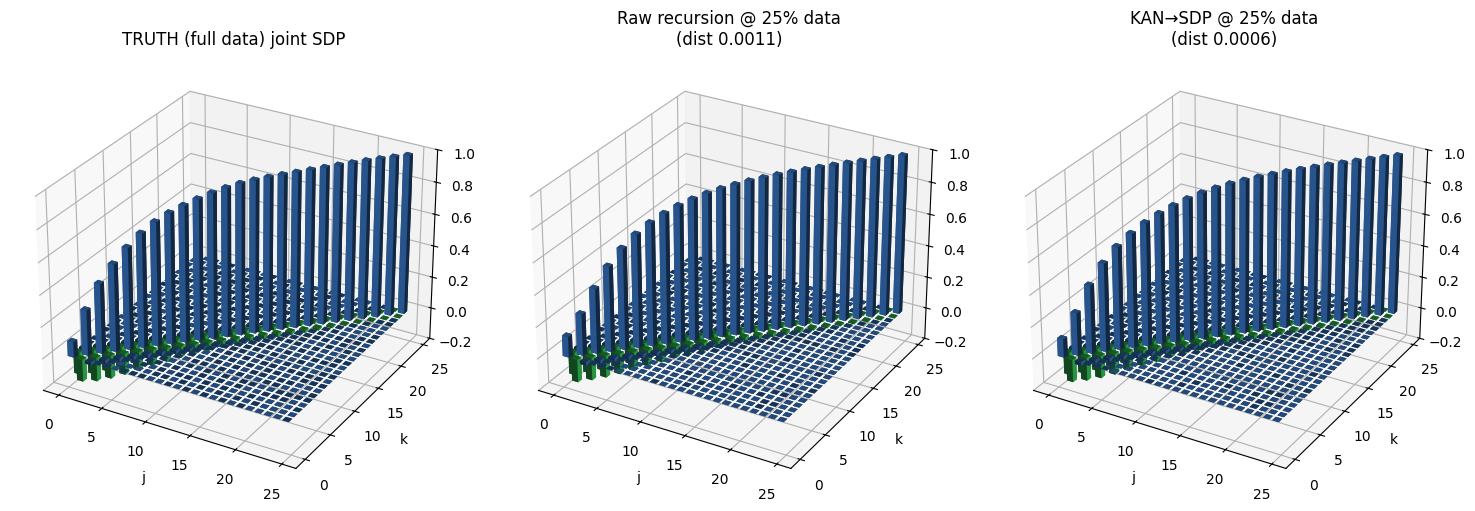

In [13]:
import numpy as np, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # noqa: enables 3D
trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

FRAC = 0.25
SEED = 3
rng = np.random.default_rng(SEED)
n_tr = max(8, int(FRAC * len(all_levels)))
train_levels = np.sort(rng.choice(all_levels, n_tr, replace=False))

# ---- (1) RAW recursion on the sparse levels ----
def reduced_raw(l):
    mags=[]; vals=[]
    for k in train_levels:
        m=keys_all==k; ph=X[m,1]%(2*np.pi); yy=y[m]; o=np.argsort(ph); ph,yy=ph[o],yy[o]
        pe=np.concatenate([ph,[ph[0]+2*np.pi]]); f=yy*np.exp(-1j*l*ph); fe=np.concatenate([f,[f[0]]])
        mags.append(np.sqrt(k)); vals.append(trapz(fe,pe)/(2*np.pi))
    return np.array(mags), np.array(vals)
Pi_raw_sparse = np.real(recursive_from_reduced(reduced_raw))

# ---- (2) KAN -> SDP on the sparse levels (KAN fills the gaps) ----
mdl, st = train_kan_on_levels(train_levels)
Xc, yc, clean_ph = kan_clean_surface(mdl, st)
keys_c = np.round(Xc[:,0],4); uniq_c = np.unique(keys_c)
def reduced_kan(l):
    return (np.sqrt(uniq_c),
            np.array([np.mean(yc[keys_c==k]*np.exp(-1j*l*Xc[keys_c==k,1])) for k in uniq_c]))
Pi_kan_sparse = np.real(recursive_from_reduced(reduced_kan))

# ---- (3) TRUTH = full-data reconstruction (use your existing Pi_joint if available) ----
try:
    Pi_truth = np.real(Pi_joint)              # from your three-way / bridge notebook
except NameError:
    # fall back: recurse on ALL levels as the reference
    def reduced_full(l):
        mags=[]; vals=[]
        for k in all_levels:
            m=keys_all==k; ph=X[m,1]%(2*np.pi); yy=y[m]; o=np.argsort(ph); ph,yy=ph[o],yy[o]
            pe=np.concatenate([ph,[ph[0]+2*np.pi]]); f=yy*np.exp(-1j*l*ph); fe=np.concatenate([f,[f[0]]])
            mags.append(np.sqrt(k)); vals.append(trapz(fe,pe)/(2*np.pi))
        return np.array(mags), np.array(vals)
    Pi_truth = np.real(recursive_from_reduced(reduced_full))

# ---- distances to truth ----
err_raw = np.sqrt(np.mean((Pi_raw_sparse - Pi_truth)**2))
err_kan = np.sqrt(np.mean((Pi_kan_sparse - Pi_truth)**2))
print("matrix-distance to truth @ %d%% data:  RAW %.4f  |  KAN->SDP %.4f"
      % (int(FRAC*100), err_raw, err_kan))

# ---- draw the three fingerprints ----
DD = 25
def draw(ax, P, title):
    xp, yp = np.meshgrid(np.arange(DD), np.arange(DD), indexing="ij")
    xp = xp.ravel(); yp = yp.ravel()
    dz = P[:DD, :DD].ravel()
    cols = ["#2BA84A" if abs(int(a)-int(b))==1 else "#2C5F9E" for a, b in zip(xp, yp)]
    ax.bar3d(xp, yp, np.zeros_like(xp, float), 0.7, 0.7, dz, color=cols, shade=True, edgecolor="none")
    ax.set_title(title); ax.set_xlabel("j"); ax.set_ylabel("k")
    ax.set_zlim(-0.2, 1.0); ax.view_init(28, -60)

fig = plt.figure(figsize=(15, 5))
draw(fig.add_subplot(1,3,1, projection="3d"), Pi_truth,      "TRUTH (full data) joint SDP")  
draw(fig.add_subplot(1,3,2, projection="3d"), Pi_raw_sparse, "Raw recursion @ %d%% data\n(dist %.4f)" % (int(FRAC*100), err_raw))
draw(fig.add_subplot(1,3,3, projection="3d"), Pi_kan_sparse, "KAN→SDP @ %d%% data\n(dist %.4f)" % (int(FRAC*100), err_kan))
plt.tight_layout(); plt.show()

/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_7376/2825509865.py:53: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(); plt.show()


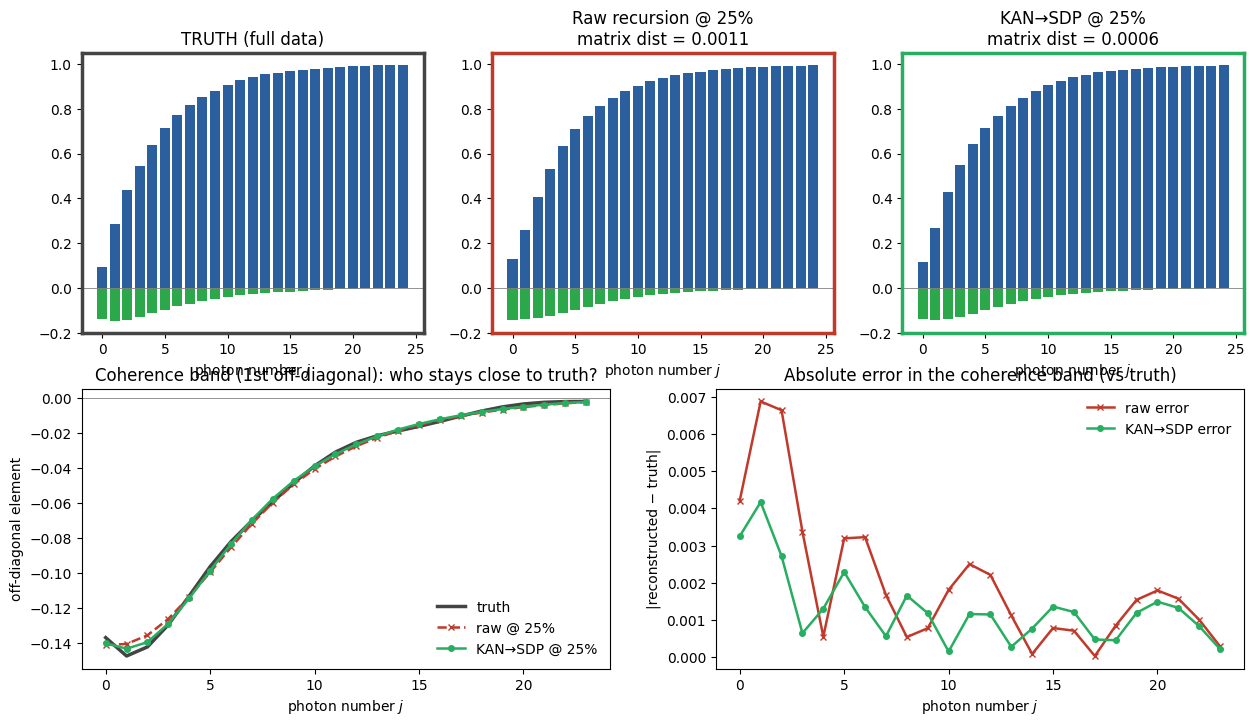

In [14]:
import numpy as np, matplotlib.pyplot as plt

# --- uses matrices already in memory from cell 26 ---
#   Pi_truth        : full-data reference
#   Pi_raw_sparse   : raw recursion @ 25% data
#   Pi_kan_sparse   : KAN->SDP @ 25% data
DD = 25
j  = np.arange(DD)

def diag0(P):  return np.real(np.diag(P))[:DD]
def diag1(P):  return np.real(np.diag(P, 1))[:DD-1]

dT, dR, dK = diag0(Pi_truth), diag0(Pi_raw_sparse), diag0(Pi_kan_sparse)
oT, oR, oK = diag1(Pi_truth), diag1(Pi_raw_sparse), diag1(Pi_kan_sparse)

errR = np.sqrt(np.mean((Pi_raw_sparse - Pi_truth)**2))
errK = np.sqrt(np.mean((Pi_kan_sparse - Pi_truth)**2))

fig = plt.figure(figsize=(15, 8))

# ---- top row: the three fingerprints as flat bar charts (diagonal navy, off-diag green) ----
def fingerprint(ax, d, o, title, frame=None):
    ax.bar(j,      d, color="#2C5F9E", label="diagonal (number)")
    ax.bar(j[:-1], o, color="#2BA84A", label="1st off-diag (coherence)")
    ax.axhline(0, color="grey", lw=.6)
    ax.set_ylim(-0.2, 1.05); ax.set_xlabel("photon number $j$")
    ax.set_title(title)
    if frame:  # colored border to flag good/bad
        for s in ax.spines.values(): s.set_color(frame); s.set_linewidth(2.5)

fingerprint(fig.add_subplot(2,3,1), dT, oT, "TRUTH (full data)", frame="#444")
fingerprint(fig.add_subplot(2,3,2), dR, oR, "Raw recursion @ 25%%\nmatrix dist = %.4f" % errR, frame="#C0392B")
fingerprint(fig.add_subplot(2,3,3), dK, oK, "KAN→SDP @ 25%%\nmatrix dist = %.4f" % errK, frame="#27AE60")

# ---- bottom-left (span 2): the OFF-DIAGONAL alone, all three overlaid (this is the punchline) ----
axo = fig.add_subplot(2,2,3)
axo.plot(j[:-1], oT, color="#444",    lw=2.5, label="truth")
axo.plot(j[:-1], oR, color="#C0392B", lw=1.8, ls="--", marker="x", ms=5, label="raw @ 25%")
axo.plot(j[:-1], oK, color="#27AE60", lw=1.8, ls="-",  marker="o", ms=4, label="KAN→SDP @ 25%")
axo.axhline(0, color="grey", lw=.6)
axo.set_title("Coherence band (1st off-diagonal): who stays close to truth?")
axo.set_xlabel("photon number $j$"); axo.set_ylabel("off-diagonal element")
axo.legend(frameon=False)

# ---- bottom-right: per-element error vs truth (how far each method drifts) ----
axe = fig.add_subplot(2,2,4)
axe.plot(j[:-1], np.abs(oR - oT), color="#C0392B", lw=1.8, marker="x", ms=5, label="raw error")
axe.plot(j[:-1], np.abs(oK - oT), color="#27AE60", lw=1.8, marker="o", ms=4, label="KAN→SDP error")
axe.set_title("Absolute error in the coherence band (vs truth)")
axe.set_xlabel("photon number $j$"); axe.set_ylabel("|reconstructed − truth|")
axe.legend(frameon=False)

plt.tight_layout(); plt.show()